Data-Driven Product Optimization at Spotify: Evaluating a New Playlist Recommendation Algorithm


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
from statsmodels.stats.power import TTestIndPower

1. Load The Dataset Spotify

In [2]:
df = pd.read_csv('spotify_campaign_data.xlsx - spotify_campaign_data.csv')


In [3]:
df.head(6)

,Group,Engagement,Duration Played,Payment,Subscription
0,Control,"0,6496714153","122,9461844",Yes,Premium
1,Control,"0,5861735699","118,0767531",Yes,Free
2,Control,"0,6647688538","148,5537227",Yes,Premium
3,Control,"0,7523029856","165,9849342",No,Premium
4,Control,"0,5765846625","140,6054083",Yes,Free
5,Control,"0,5765863043","150,3463125",No,Premium


In [4]:
df.columns

Index(['Group', 'Engagement', 'Duration Played', 'Payment', 'Subscription'], dtype='object')

In [5]:
df.shape

(100000, 5)

2. Checking The Integrity Of The Dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Group            100000 non-null  object
 1   Engagement       100000 non-null  object
 2   Duration Played  100000 non-null  object
 3   Payment          100000 non-null  object
 4   Subscription     100000 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


Because Of The Dataset Contain Data Type Which Not Correct To The Correct Data Type For Certain Columns In The Dataset, Therefore Need To Change Them.

In [7]:
df['Engagement'].unique()[:20]
df['Duration Played'].unique()[:20]

array(['122,9461844', '118,0767531', '148,5537227', '165,9849342',
       '140,6054083', '150,3463125', '113,477873', '123,7621442',
       '164,5719622', '135,8013438', '112,7391037', '120,9765166',
       '151,1145387', '153,7868103', '94,73606575', '130,8777383',
       '119,7647147', '118,0339246', '159,9092385', '112,8738558'],
      dtype=object)

In [8]:
df['Engagement'] = df['Engagement'].str.replace(',','.', regex=False)
df['Duration Played'] = df['Duration Played'].str.replace(',','.', regex=False)

df['Engagement'] = pd.to_numeric(df['Engagement'])
df['Duration Played'] = pd.to_numeric(df['Duration Played'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Group            100000 non-null  object 
 1   Engagement       100000 non-null  float64
 2   Duration Played  100000 non-null  float64
 3   Payment          100000 non-null  object 
 4   Subscription     100000 non-null  object 
dtypes: float64(2), object(3)
memory usage: 3.8+ MB


In [10]:
df.head()

,Group,Engagement,Duration Played,Payment,Subscription
0,Control,0.649671,122.946184,Yes,Premium
1,Control,0.586174,118.076753,Yes,Free
2,Control,0.664769,148.553723,Yes,Premium
3,Control,0.752303,165.984934,No,Premium
4,Control,0.576585,140.605408,Yes,Free


Checking If Duplicated Data Exist :

Duplicate data can be entered into both the Control and Target groups.

- This undermines randomization.

- This undermines statistical validity.

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()].head() # If you want more details.

,Group,Engagement,Duration Played,Payment,Subscription


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Group            100000 non-null  object 
 1   Engagement       100000 non-null  float64
 2   Duration Played  100000 non-null  float64
 3   Payment          100000 non-null  object 
 4   Subscription     100000 non-null  object 
dtypes: float64(2), object(3)
memory usage: 3.8+ MB


In [15]:
df.head()

,Group,Engagement,Duration Played,Payment,Subscription
0,Control,0.649671,122.946184,Yes,Premium
1,Control,0.586174,118.076753,Yes,Free
2,Control,0.664769,148.553723,Yes,Premium
3,Control,0.752303,165.984934,No,Premium
4,Control,0.576585,140.605408,Yes,Free


Features :

- Variant Name :

a. Control Group: Users using the current version of Spotify.

b. Target Group: Users using new features or changes.

c. User Engagement: Number of playlists created, number of songs played, time spent in the app.

d. Feature Interaction: Frequency of use of new features.

3. EDA AND TEST DESIGN

In [16]:
df[['Engagement', 'Duration Played']].describe()

,Engagement,Duration Played
count,100000.000000,100000.000000
mean,0.699842,139.991775
std,0.141362,36.040271
min,0.153440,-13.889056
25%,0.594898,115.065024
50%,0.699695,139.992180
75%,0.805039,165.020973
max,1.178219,286.580990


1. RANDOMIZATION CHECK : Make sure the distribution of users in each group is random.

In [17]:
df['Group'].value_counts()

Group
Control    50000
Target     50000
Name: count, dtype: int64

The sample size is evenly split between Control and Target groups, indicating balanced group allocation.

<Axes: xlabel='Group', ylabel='count'>

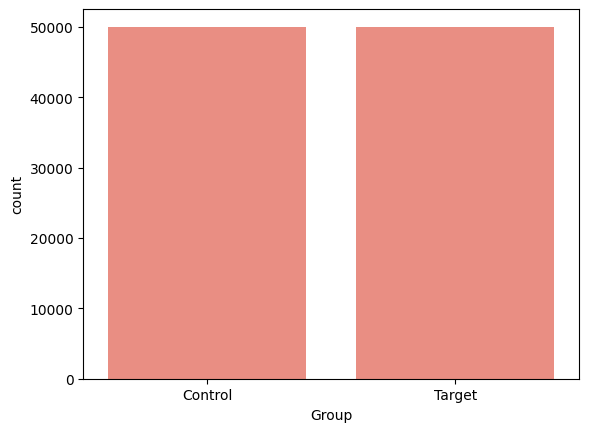

In [18]:
sns.countplot(data=df, x='Group', color='salmon')

The dataset shows an equal allocation of users across experimental groups, with 50,000 users in both the Control and Target groups. This balanced group size strengthens the reliability of the A/B test by improving statistical power and reducing potential allocation bias.

<Axes: xlabel='Group', ylabel='Engagement'>

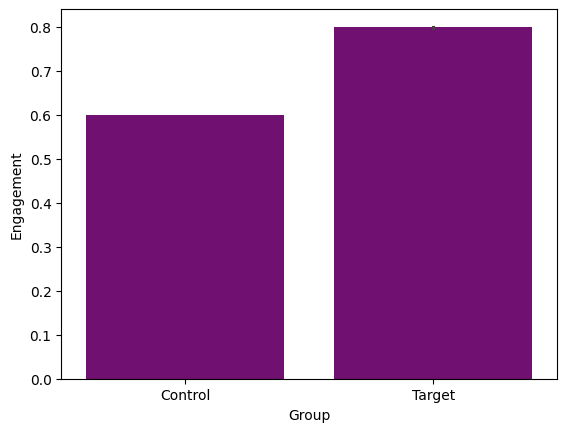

In [19]:
sns.barplot(data=df, x='Group', y='Engagement', color='purple')

<Axes: xlabel='Group', ylabel='Duration Played'>

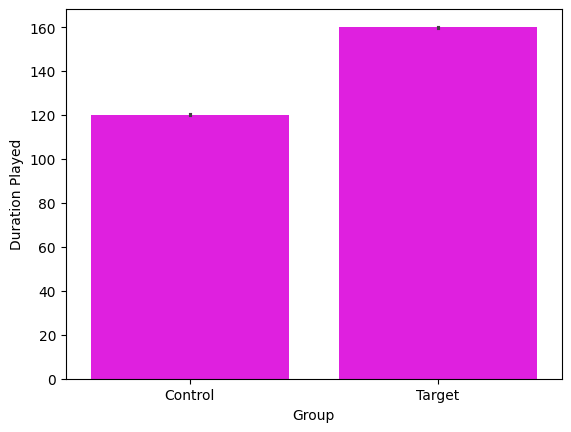

In [20]:
sns.barplot(data=df, x='Group', y='Duration Played', color='magenta')

In [21]:
df.groupby('Group')[['Engagement','Duration Played']].mean()

,Engagement,Duration Played
Group,,
Control,0.599958,120.070639
Target,0.799726,159.912912


-----------------------------------------

From Simple Mean Calculation Based On Group Control Vs Target :

1. From Engagement :
- 0.7997 − 0.5999 = 0.1998 ((0.1998 / 0.5999) x 100 %) ≈ +33%

2. From Duration Played :
- 159.91 − 120.07 = 39.84 menit ((39.84 / 120.07) x 100 %) ≈ +33%

Conclusion : 

- Spotify's new feature appears to increase engagement and listening time by around 30–35%.

- BUT :We can't claim this is true until statistical testing is done.

----------------------------------------------------

There are 2 possible scenarios from the dataset based on the descriptive statistical test / EDA that I have conducted, namely:

1. If this is experimental data (after treatment):

- While the sample size between groups is balanced, there is a substantial difference in average engagement and duration. This suggests a strong treatment effect rather than a random imbalance

2. If this is checked as randomization quality:

- Although the number of users is balanced, the observed differences in group means indicate that we cannot rely solely on sample size to validate randomization. Further statistical testing is required to confirm whether this difference is statistically significant.













--------------------------------------------------------

IN CONCLUSION :

The Control and Target groups contain an equal number of users, confirming balanced sample allocation. However, observed differences in engagement and listening duration are substantial, suggesting a potentially meaningful treatment effect. Further statistical testing is required to determine whether these differences are statistically significant.

--------------------------------------

2. POWER ANALYSIS CHECK = Peluang kita berhasil mendeteksi efek yang benar-benar ada.

Ideally, power analysis is conducted before experimentation to determine required sample size. However, since this dataset is pre-collected, a post-hoc power analysis is used to evaluate whether the current sample size provides sufficient statistical power.

In [22]:
control = df[df['Group'] == 'Control']['Engagement']
target = df[df['Group'] == 'Target']['Engagement']

n_control = len(control)
n_target = len(target)

mean_control = control.mean()
mean_target = target.mean()

std_control = control.std()
std_target = target.std()


In [23]:
n_control, n_target, mean_control, mean_target

(50000, 50000, np.float64(0.599957910142026), np.float64(0.7997263213101301))

EFFECT SIZE (COHEN'S D)

In [24]:
pooled_std = np.sqrt(((n_control-1) * std_control**2 + (n_target - 1) * std_target **2) 
                     / (n_control + n_target - 2))

cohens_d = round((mean_target - mean_control) / pooled_std, 3)

cohens_d

np.float64(1.997)

-------------------------

Target's average engagement was almost 2 standard deviations higher than Control's.

------------------------

POWER (POST-HOC POWER ANALYSIS).

Power = Area under the alternative distribution curve.

In [25]:
analysis = TTestIndPower()

power = analysis.power(
    effect_size=cohens_d,
    nobs1=n_control,
    ratio=n_target / n_control,
    alpha=0.05
)
power 

np.float64(1.0)

In [26]:
from scipy.stats import t

alpha = 0.05
dfree = n_control + n_target - 2
se = pooled_std * np.sqrt(1/n_control + 1/n_target)

t_crit = t.ppf(1 - alpha / 2, dfree)
t_effect = (mean_target - mean_control) / se

power_t = t.cdf(t_effect - t_crit, dfree) + (1 - t.cdf(t_effect + t_crit, dfree))

t_crit, t_effect, power_t


(np.float64(1.9599877080090842), np.float64(315.761753283785), np.float64(1.0))

--------------------------------------

The effect size (Cohen’s d = 1.997) indicates a very large behavioral difference in engagement between the Control and Target groups. A post-hoc power analysis shows statistical power close to 1.0, meaning the experiment has an extremely high probability of detecting this effect. Therefore, the current sample size is more than sufficient, and the observed difference is statistically reliable.

The engagement difference between groups is very large.
With 100,000 users, the experiment has near-perfect statistical power, meaning results are highly reliable and unlikely to be due to chance.

--------------------------------------------------

3. Experiment duration = How long does it take to collect the minimum sample size required for power analysis?

- Duration = (Sample Size Needed / Users Per Day)
	​



- Statistically, the amount of data is more than sufficient.

- Now, duration is no longer about lack of data —
but about the stability of user behavior.

WHY CAN'T IT BE TOO SHORT?

If it's only 1–3 days:

- ❌ It can be a weekend versus weekday option

- ❌ It can be a temporary promotion

- ❌ It can be a novelty effect (new users trying out the feature)

Risk: User behavior is unstable.

----------------------------------------------------------------

The experiment duration was set to approximately 2–4 weeks to ensure sufficient data collection, capture multiple weekly behavioral cycles, and allow user behavior to stabilize. This reduces the risk of short-term bias and improves the reliability of the experimental results.

While the required sample size could theoretically be reached in a few days, short test durations risk behavioral bias due to novelty effects, daily usage fluctuations, and temporary user reactions. A multi-week duration ensures the observed impact reflects sustainable user behavior rather than short-term noise.

| Company Size | Typical Duration |
| -------------------------------- | ----------- |
| Small startup | 1–2 weeks |
| Mid-size product | 2–4 weeks |
| Big tech (Spotify, Google, Meta) | 2–6 weeks |


----------------------------------------------

4. STATISTICAL TESTING

1. Check for normality first.

- If normal, check for homogeneity of variance.

- If not normal, use a non-parametric test.



PURPOSE OF THE SHAPIRO TEST :

Before conducting a statistical test, we must check the following assumptions:

- Is the distribution of engagement per group normal?

- If normal, use the t-test.

- If not normal, use the Mann–Whitney U test.

SHAPIRO TEST HYPOTHESIS :

- H₀ (Null Hypothesis): Data follows a normal distribution

- H₁ (Alternative Hypothesis): Data does not follow a normal distribution

-----------------------------------

| Approach | Valid? | Suitable for |
| ------------------ | ------ | --------------------------------- |
| (full data) | ✅ | Small data |
| Sampling (5000) | ✅ | Big data (like your Spotify) |

SHAPIRO'S PROBLEM WITH LARGE DATA (THIS IS KEY TO UNDERSTANDING)
Shapiro is very sensitive.

- If the data is > 5,000–10,000:
👉 Even a slight deviation → the p-value is immediately 0.000

- This means: Not because the data is "severely abnormal,"
but because the test is too sensitive.

SAMPLING?
Because we want to:

- ✅ Test the SHAPE of the distribution, not penalize small noise.

- ✅ Obtain fair methodological decisions.

- ✅ Avoid false rejection.

This is a common statistical practice in:

- Research

- Data science

- Big tech experimentation.

WHY IS BIG DATA “PUNISHED”?

Because Shapiro detects: The slightest deviation from normality → is considered significant.

In fact:

- A little skew

- A little kurtosis

- A little outlier
is normal in human data.

But Shapiro says: “This is not normal!” even though it is practically normal enough for a t-test.

| Data Quantity | Shapiro Quality |
| ----------- | ---------------------------------------- |
| < 50 | Too small (weak) |
| 50 – 500 | Good |
| 500 – 5,000 | **Ideal & stable** |
| > 5,000 | Too sensitive (over-rejects normality) |

Because the dataset contains a very large number of users, Shapiro–Wilk becomes overly sensitive and tends to reject normality even for minor deviations. Therefore, we tested normality on a representative random sample to obtain a more reliable distribution assessment.

----------------------------------

But for large datasets like Spotify,
Shapiro sampling is more methodological and fairer.

In [27]:
from scipy.stats import shapiro

In [28]:
control_sample = control.sample(n=5000, random_state=42)
target_sample = target.sample(n=5000, random_state=42)

shapiro_control = shapiro(control_sample)
shapiro_target = shapiro(target_sample)


In [29]:
print(f"{shapiro_control}")
print(f"{shapiro_target}")

ShapiroResult(statistic=np.float64(0.9994609101267378), pvalue=np.float64(0.16006665533301068))
ShapiroResult(statistic=np.float64(0.9996737050657837), pvalue=np.float64(0.6267313185643818))


Scientific conclusion: Both groups showed distributions consistent with normality.

- A Shapiro statistic close to 1.0 means: The data distribution is very close to normal.

- A large p-value means: The small deviations are not large enough to be considered significant.

This is a strong indication that the data are normal enough for a t-test.



Because:

- Normal distribution

- Large sample size

- Central Limit Theorem applies

👉 We USE INDEPENDENT T-TEST

This is a scientific and defensible decision.

The Shapiro–Wilk test indicates no statistically significant deviation from normality for both Control (p = 0.160) and Target (p = 0.627). Therefore, the assumption of normal distribution is satisfied, and an independent samples t-test is appropriate.

----------------------------------------

2. T-Test Testing

1. Hypothesis: Users using the new playlist algorithm will have higher engagement rates than users using the current algorithm.

2. Null Hypothesis: There is no significant difference in user engagement between the two groups.

Check the Variance of Spotify Data First Before Starting the T-Test to Check the Difference in Variance So You Can Later Choose Whether to Use the Student's T-Test or Welch's T-Test.

In [30]:
print(f"Varians Control Group {round(control.var(), 4)}")
print(f"Varians Target Group: {round(target.var(), 4)}")

Varians Control Group 0.01
Varians Target Group: 0.01


- ✅ The variances of both groups are practically the same.

- ✅ The assumption of equal variances is not significantly violated.

SO IS equal_var=True OK? Statistically:

- 👉 Yes, because the variances are nearly identical. So it's not wrong to use the Student's t-test.

But is it recommended to use equal_var=False? Because the Welch's t-test:

- ✅ Remains valid if the variances are equal.

- ✅ Remains valid if the variances are different.

- ✅ Safer as a default.

- ✅ Doesn't harm the results.

The simple logic:

- If the variances are equal → Welch's is still correct.

- If the variances are different → Welch's is still correct.

- But the Student's t-test can be wrong if the variances are different.

👉 So the Welch's is more universal and robust.

In [31]:
from scipy.stats import ttest_ind

In [32]:
t_stat, p_value = ttest_ind(a=target, b=control, equal_var=False)

print(f"t-Statistic : {t_stat:.3f}")
print(f"p-Value: {p_value:.6f}")

t-Statistic : 315.762
p-Value: 0.000000


The independent t-test shows a statistically significant difference in Engagement between the Target and Control groups (t = 315.76, p < 0.001).
This indicates that the observed performance lift in the Target group is extremely unlikely to be caused by random variation.

A. Key findings:

- Users in the Target group demonstrate substantially higher engagement compared to the Control group.

B. Business significance:

- Experimental features/treatments are highly effective

- Large and tangible impact, not noise

- Worth considering for rollout to all users

IN CONCLUSION FOR RESULT OF THIS STATISTICAL TESTING :

Given the large effect size and extremely strong statistical significance, the Target variant should be considered for full deployment.
Further monitoring is recommended to ensure long-term retention and revenue sustainability.

--------------------------------------

So, Methodologically: IS MANN–WHITNEY REQUIRED?
❌ Not necessary:

Because Mann–Whitney is used if:

- Data is not normal

- There are extreme outliers

- Small sample size

BUT ✅ It can be used as a robustness check.

3. Mann-Whitney Testing.

In [33]:
from scipy.stats import mannwhitneyu

In [34]:
u_stat, p_value_MW = mannwhitneyu(x=target, y=control, alternative='two-sided')
print(f"Mann-Whitney U Statistic: {u_stat:.3f}")
print(f"Mann-Whitney p-Value: {p_value_MW:.6f}")

Mann-Whitney U Statistic: 2302457679.500
Mann-Whitney p-Value: 0.000000


4. Z-Test Testing.

DO YOU NEED A Z-TEST?
Theoretically, a T-test = a Z-test if the sample size is large. Because: 𝑛 > 30 → 𝑡 ≈ 𝑧

So:

- ❌ Not required.

- ✅ But it can be shown as theoretical confirmation.

In [35]:
from statsmodels.stats.weightstats import ztest

Z_stat, p_value_Z = ztest(x1=target, x2=control)
print(f"Z-Statistic: {Z_stat:.3f}")
print(f"Z Test P-Value: {p_value_Z:.6f}")

Z-Statistic: 315.762
Z Test P-Value: 0.000000


-------------------------------------------

IN CONCLUSION FROM ALL OF THOSE STATISTICAL TEST :

T-Statistic :

t-Statistic: 315.762

p-Value: 0.000000

Significance: The difference in the means is MUCH greater than the variance in the data.

- The probability of this difference occurring by chance is ≈ zero.

- 📌 Reject H₀ → There is a significant difference.


-----------------------------------------------------


Mann–Whitney (non-parametric):

U = 2,302,457,679.5

p-Value = 0.000000

Logical significance: Mann–Whitney compares the ranking of Target vs. Control values.

If:

- Target values ​​are often larger → U is large

- Values ​​are balanced → U is close to the middle

📌 The results show: Target values ​​are almost always larger than Control values.

-------------------------------------------

Z-Test :

Z = 315.762

p-Value = 0.000000

Meaning: Z-score = 315 standard deviations from zero

Compare:

a. Z = 2 → already significant

b. Z = 3 → very significant

c. Z = 315 → EXTREME

📌 This is a statistically significant effect.

-----------------------------------------------------

| Test | Assumptions | Results |
| ------------ | -------------- | ------------ |
| T-Test | Normal approximation | ✅ Significant |
| Mann–Whitney | Non-parametric | ✅ Significant |
| Z-Test | Large sample | ✅ Significant |

Meaning: These results are ROBUST — independent of statistical methods.

--------------------------------------------

FINAL CONCLUSION :

Statistical Interpretation :

- Both parametric (t-test, z-test) and non-parametric (Mann–Whitney U) tests indicate a statistically significant difference in user engagement between the Control and Target groups (p < 0.001). The Target group consistently demonstrates higher engagement, suggesting that the new Spotify feature has a strong positive effect.

Business Insight :

- Users exposed to the new recommendation system show substantially higher engagement levels.
This suggests that the new feature increases listening time and user interaction, which may lead to improved retention and monetization opportunities.

